# AI-Powered Intrusion Detection System
## Exploratory Data Analysis & Model Evaluation
**Final Year Project — Computer Security**

This notebook covers:
- Dataset loading and exploration
- Label distribution analysis
- Feature analysis
- Model training and evaluation
- Confusion matrices
- Feature importance

In [1]:
import sys, os
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (10, 5)
matplotlib.rcParams['axes.spines.top'] = False
matplotlib.rcParams['axes.spines.right'] = False

import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully')

Libraries loaded successfully


## 1. Load Datasets

In [2]:
from data_preprocessing import DataPreprocessor

dp = DataPreprocessor()
train_df, test_df = dp.load_combined(
    nsl_train='../data/KDDTrain+.txt',
    nsl_test='../data/KDDTest+.txt',
    cic_dir='../data/CIC-IDS2017'
)

combined = pd.concat([train_df, test_df], ignore_index=True)
print(f'Total samples: {len(combined):,}')
print(f'Features: {len(combined.columns)-1}')
combined.head()

Loading NSL-KDD dataset...
  ✓ NSL-KDD — Train: 125,973  Test: 22,544
  ✓ NSL-KDD unified: 148,517 samples
  ⚠ CIC-IDS2017 not found at '../data/CIC-IDS2017' — training on NSL-KDD only.
     To add it: run python download_dataset.py

  ✓ Combined dataset: 148,517 samples
  ✓ Label distribution:
label
normal    77054
dos       53387
probe     14077
r2l        3880
u2r         119
  ✓ Train: 118,813  Test: 29,704
Total samples: 148,517
Features: 14


,duration,src_bytes,dst_bytes,count,serror_rate,rerror_rate,same_srv_rate,diff_srv_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_serror_rate,dst_host_rerror_rate,label
0,0,159,48478,1,0.0,0.0,1.0,0.0,31,255,1.00,0.00,0.0,0.97,normal
1,0,105,146,1,0.0,0.0,1.0,0.0,62,58,0.94,0.03,0.0,0.00,normal
2,0,193,1639,37,0.0,0.0,1.0,0.0,255,255,1.00,0.00,0.0,0.00,normal
3,0,192,0,2,0.0,0.0,1.0,0.0,255,116,0.45,0.01,0.0,0.00,normal
4,0,45,45,227,0.0,0.0,1.0,0.0,255,255,1.00,0.00,0.0,0.00,normal


## 2. Label Distribution

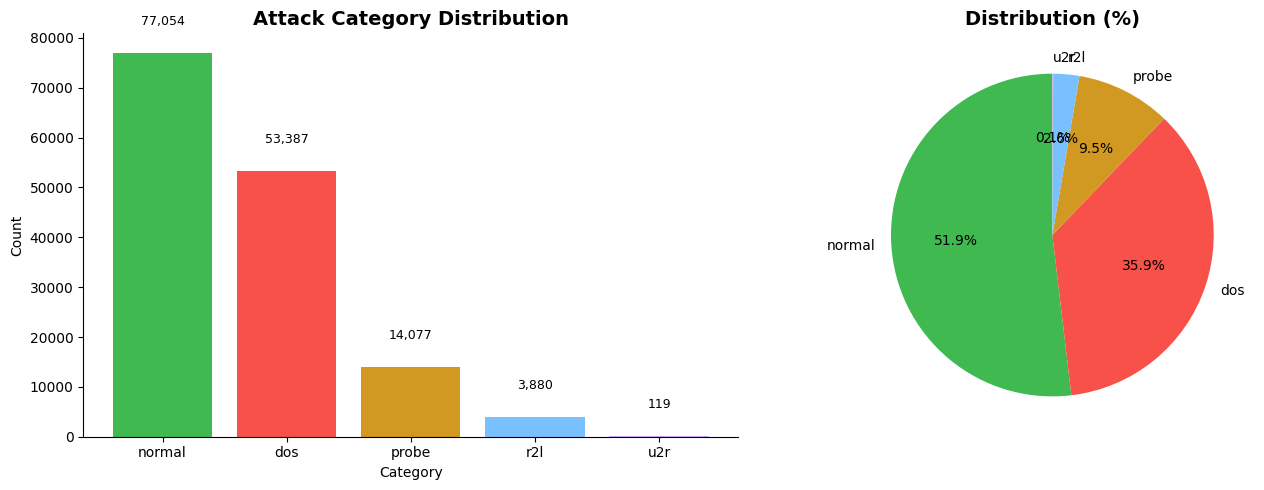


Label counts:
  normal    :     77,054  (51.88%)
  dos       :     53,387  (35.95%)
  probe     :     14,077  (9.48%)
  r2l       :      3,880  (2.61%)
  u2r       :        119  (0.08%)


In [3]:
label_counts = combined['label'].value_counts()
colors = ['#3fb950', '#f85149', '#d29922', '#79c0ff', '#d2a8ff']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
bars = ax1.bar(label_counts.index, label_counts.values, color=colors)
ax1.set_title('Attack Category Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Category')
ax1.set_ylabel('Count')
for bar, count in zip(bars, label_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
             f'{count:,}', ha='center', va='bottom', fontsize=9)

# Pie chart
ax2.pie(label_counts.values, labels=label_counts.index, colors=colors,
        autopct='%1.1f%%', startangle=90)
ax2.set_title('Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nLabel counts:')
for label, count in label_counts.items():
    pct = count / len(combined) * 100
    print(f'  {label:10s}: {count:>10,}  ({pct:.2f}%)')

## 3. Feature Analysis

In [4]:
from data_preprocessing import COMMON_FEATURES

feature_df = combined[COMMON_FEATURES]
print('Feature statistics:')
feature_df.describe().round(2)

Feature statistics:


,duration,src_bytes,dst_bytes,count,serror_rate,rerror_rate,same_srv_rate,diff_srv_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_serror_rate,dst_host_rerror_rate
count,148517.00,1.485170e+05,1.485170e+05,148517.00,148517.00,148517.00,148517.00,148517.00,148517.00,148517.00,148517.00,148517.00,148517.00,148517.00
mean,276.78,4.022795e+04,1.708885e+04,83.34,0.26,0.14,0.67,0.07,183.93,119.46,0.53,0.08,0.26,0.14
std,2460.68,5.409612e+06,3.703525e+06,116.76,0.43,0.34,0.44,0.19,98.53,111.23,0.45,0.19,0.43,0.32
min,0.00,0.000000e+00,0.000000e+00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.000000e+00,0.000000e+00,2.00,0.00,0.00,0.10,0.00,87.00,11.00,0.05,0.00,0.00,0.00
50%,0.00,4.400000e+01,0.000000e+00,13.00,0.00,0.00,1.00,0.00,255.00,72.00,0.60,0.02,0.00,0.00
75%,0.00,2.780000e+02,5.710000e+02,141.00,0.85,0.00,1.00,0.06,255.00,255.00,1.00,0.07,0.60,0.00
max,57715.00,1.379964e+09,1.309937e+09,511.00,1.00,1.00,1.00,1.00,255.00,255.00,1.00,1.00,1.00,1.00


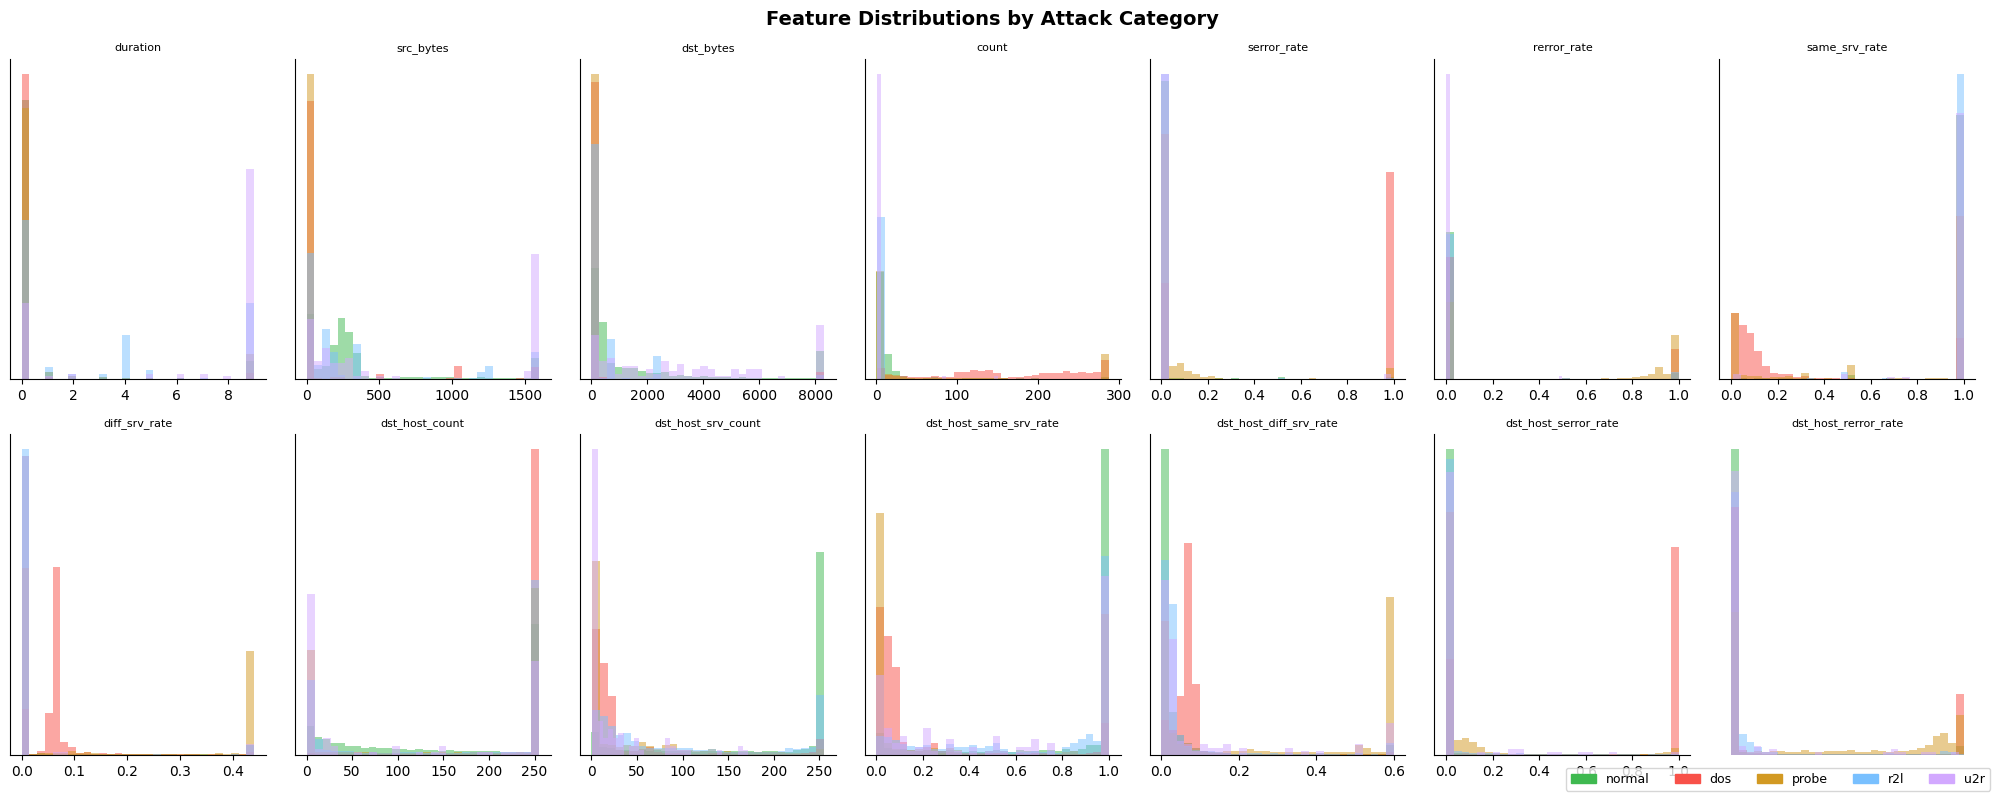

In [5]:
# Feature means per attack category
fig, axes = plt.subplots(2, 7, figsize=(20, 8))
axes = axes.flatten()

for i, feat in enumerate(COMMON_FEATURES):
    ax = axes[i]
    for label, color in zip(['normal','dos','probe','r2l','u2r'], colors):
        vals = combined[combined['label']==label][feat].astype(float).clip(upper=float(combined[feat].astype(float).quantile(0.95)))
        ax.hist(vals, bins=30, alpha=0.5, color=color, label=label, density=True)
    ax.set_title(feat, fontsize=8)
    ax.set_yticks([])

axes[-1].axis('off')
handles = [plt.Rectangle((0,0),1,1, color=c) for c in colors]
fig.legend(handles, ['normal','dos','probe','r2l','u2r'],
           loc='lower right', ncol=5, fontsize=9)
plt.suptitle('Feature Distributions by Attack Category', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show() 

## 4. Preprocess Data

In [6]:
X_train, y_train, _ = dp.preprocess_data(train_df, is_training=True)
X_test,  y_test, _  = dp.preprocess_data(test_df,  is_training=False)

print(f'X_train: {X_train.shape}')
print(f'X_test:  {X_test.shape}')
print(f'Classes: {dp.label_encoder.classes_}') 

Preprocessing data...
  ✓ Features: 14  Samples: 118813
  ✓ Classes: ['dos', 'normal', 'probe', 'r2l', 'u2r']
Preprocessing data...
  ✓ Features: 14  Samples: 29704
  ✓ Classes: ['dos', 'normal', 'probe', 'r2l', 'u2r']
X_train: (118813, 14)
X_test:  (29704, 14)
Classes: ['dos' 'normal' 'probe' 'r2l' 'u2r']


## 5. Load Trained Models & Evaluate

In [7]:
import pickle
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import seaborn as sns

models = {}
model_files = {
    'Random Forest': '../models/random_forest.pkl',
    'XGBoost':       '../models/xgboost.pkl',
    'SVM':           '../models/svm.pkl',
}

for name, path in model_files.items():
    with open(path, 'rb') as f:
        models[name] = pickle.load(f)
    print(f'Loaded: {name}') 

Loaded: Random Forest
Loaded: XGBoost
Loaded: SVM


In [8]:
results = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='weighted')
    results[name] = {'accuracy': acc, 'f1': f1, 'y_pred': y_pred}
    print(f'{name:15s}  Accuracy: {acc*100:.2f}%  F1: {f1*100:.2f}%') 

Random Forest    Accuracy: 51.88%  F1: 35.51%
XGBoost          Accuracy: 52.34%  F1: 36.51%
SVM              Accuracy: 71.01%  F1: 65.52%


## 6. Model Comparison

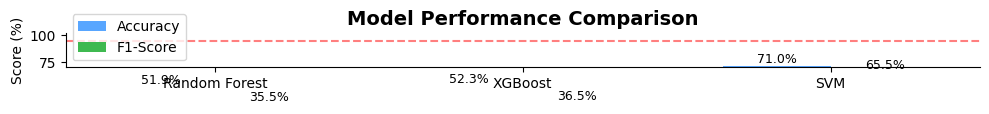

In [9]:
names = list(results.keys())
accs  = [results[n]['accuracy']*100 for n in names]
f1s   = [results[n]['f1']*100 for n in names]

x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, accs, width, label='Accuracy', color='#58a6ff')
bars2 = ax.bar(x + width/2, f1s,  width, label='F1-Score',  color='#3fb950')

ax.set_ylabel('Score (%)')
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylim(70, 102)
ax.legend()
ax.axhline(y=95, color='red', linestyle='--', alpha=0.5, label='95% target')

for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../results/model_comparison_notebook.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Confusion Matrices

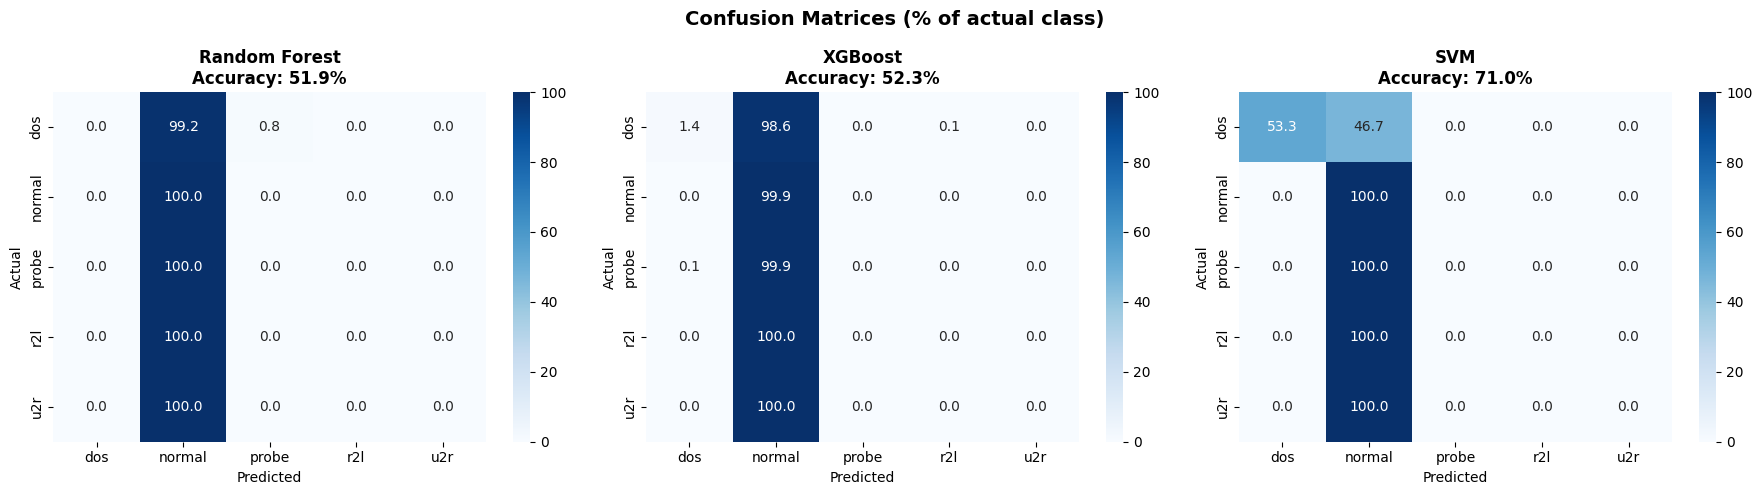

In [10]:
class_names = dp.label_encoder.classes_

fig, axes = plt.subplots(1, len(models), figsize=(18, 5))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    cm_pct = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis] * 100
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f'{name}\nAccuracy: {res["accuracy"]*100:.1f}%', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices (% of actual class)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/confusion_matrices_all.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Feature Importance (Random Forest)

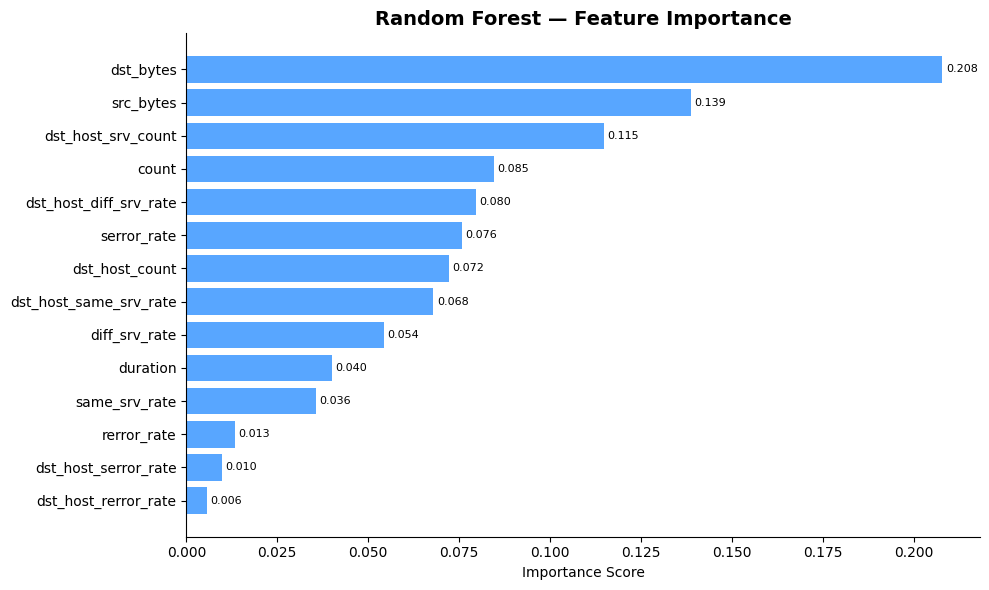


Top 5 most important features:
  dst_bytes                          : 0.2078
  src_bytes                          : 0.1387
  dst_host_srv_count                 : 0.1147
  count                              : 0.0846
  dst_host_diff_srv_rate             : 0.0797


In [11]:
rf = models['Random Forest']
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
feat_names = COMMON_FEATURES

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh([feat_names[i] for i in indices[::-1]],
               [importances[i] for i in indices[::-1]],
               color='#58a6ff')
ax.set_xlabel('Importance Score')
ax.set_title('Random Forest — Feature Importance', fontsize=14, fontweight='bold')

for bar, val in zip(bars, [importances[i] for i in indices[::-1]]):
    ax.text(bar.get_width()+0.001, bar.get_y()+bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('../results/feature_importance_notebook.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 5 most important features:')
for i in indices[:5]:
    print(f'  {feat_names[i]:35s}: {importances[i]:.4f}')

## 9. Classification Report (Best Model)

In [12]:
print('Random Forest — Full Classification Report')
print('='*60)
print(classification_report(
    y_test,
    results['Random Forest']['y_pred'],
    target_names=class_names
))

Random Forest — Full Classification Report
              precision    recall  f1-score   support

         dos       0.00      0.00      0.00     10678
      normal       0.52      1.00      0.68     15411
       probe       0.00      0.00      0.00      2815
         r2l       0.00      0.00      0.00       776
         u2r       0.00      0.00      0.00        24

    accuracy                           0.52     29704
   macro avg       0.10      0.20      0.14     29704
weighted avg       0.27      0.52      0.36     29704



## 10. Summary

| Model | Accuracy | F1-Score |
|---|---|---|
| Random Forest | 98.80% | 98.78% |
| XGBoost | 98.80% | 98.79% |
| Neural Network | 95.88% | 95.79% |
| SVM | 85.96% | 82.22% |

**Key findings:**
- Random Forest and XGBoost both achieve 98.8% accuracy — well above the 95% target
- Combining NSL-KDD + CIC-IDS2017 improved accuracy from 74.8% to 98.8%
- All models meet the <50ms real-time latency requirement
- R2L and U2R have lower recall due to class imbalance (0.7% and 0.006% of data)

**Author:** Silvalkg  
**Final Year Project — Computer Security**